In [3]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from src.config import load_abm_sim_cfg, load_bm_sweep_cfg
from src.paths import BM_RESULTS_DIR

from abm.flow_field import FlowField
from abm.cell_agent import CellAgent
from abm.rho_lookup_table import RhoLookupTable
from abm.scripts.run_abm_sim import plot_cell

cfg = load_abm_sim_cfg()
lut = RhoLookupTable(cfg, BM_RESULTS_DIR)

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


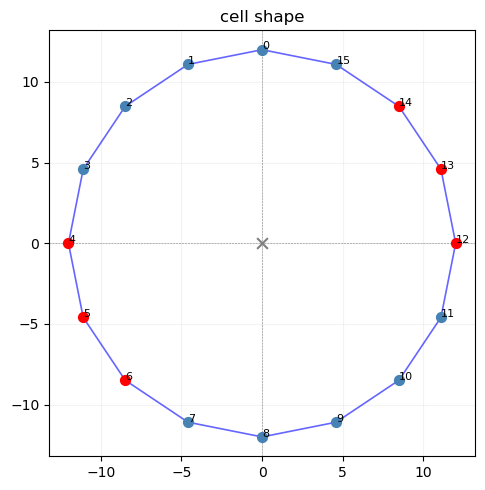

In [4]:
dt = cfg['simulation'].get('dt', 0.1)

# Initiate flowfield and cell
flow = FlowField(cfg)
cell = CellAgent( 
    cell_id=0, flow_axis=flow.direction,
    lut=lut, cfg=cfg
)
plot_cell(cell)

In [5]:
pos = cell.positions
pos

array([[ 7.34788079e-16,  1.20000000e+01],
       [-4.59220119e+00,  1.10865544e+01],
       [-8.48528137e+00,  8.48528137e+00],
       [-1.10865544e+01,  4.59220119e+00],
       [-1.20000000e+01,  1.46957616e-15],
       [-1.10865544e+01, -4.59220119e+00],
       [-8.48528137e+00, -8.48528137e+00],
       [-4.59220119e+00, -1.10865544e+01],
       [-2.20436424e-15, -1.20000000e+01],
       [ 4.59220119e+00, -1.10865544e+01],
       [ 8.48528137e+00, -8.48528137e+00],
       [ 1.10865544e+01, -4.59220119e+00],
       [ 1.20000000e+01, -2.93915232e-15],
       [ 1.10865544e+01,  4.59220119e+00],
       [ 8.48528137e+00,  8.48528137e+00],
       [ 4.59220119e+00,  1.10865544e+01]])

In [11]:
pos.mean(axis=0), cell.centroid

(array([ 3.88578059e-16, -1.11022302e-16]),
 array([ 3.88578059e-16, -1.11022302e-16]))

In [15]:
vec = pos - cell.centroid
eigvals, eigvecs = np.linalg.eigh(np.cov(vec.T))
eigvals, eigvecs

(array([76.8, 76.8]),
 array([[0., 1.],
        [1., 0.]]))

In [16]:
eigvals   = np.maximum(eigvals, 0.0)

minor = 2.0 * np.sqrt(eigvals[0])
major = 2.0 * np.sqrt(eigvals[1])
major, minor

(np.float64(17.527121840165318), np.float64(17.527121840165314))